In [2]:
import sys
import os
import libcontext

In [47]:
import torch
import numpy as np
from typing import cast, List, Optional, Union
from tqdm import tqdm
import pandas as pd
import seaborn as sns
import time
import math

from torch.optim import Optimizer

In [ ]:
def update_uv_with_brand(U, Sigma, V, beta_g, g_bar_col, max_rank):
    # orthogonalizing new columns
    u_residual = beta_g - U @ (U.T @ beta_g)
    v_residual = g_bar_col - V @ (V.T @ g_bar_col)
    
    u_residual_norm = torch.norm(u_residual, p=2)
    v_residual_norm = torch.norm(v_residual, p=2)
    
    if u_residual_norm > 1e-8:
        u_residual = u_residual / u_residual_norm
    else:
        u_residual = torch.zeros_like(u_residual)
    
    if v_residual_norm > 1e-8:
        v_residual = v_residual / v_residual_norm
    else:
        v_residual = torch.zeros_like(v_residual)

    # intermidiate matrix M
    B = torch.cat([U.T @ beta_g, u_residual_norm.unsqueeze(0).unsqueeze(1)], dim=0)  # (r+1, 1)
    C = torch.cat([V.T @ g_bar_col, v_residual_norm.unsqueeze(0).unsqueeze(1)], dim=0)  # (r+1, 1)
    M = torch.diag(torch.cat([Sigma, torch.zeros(1, device=U.device)])) + B @ C.T  # (r+1, r+1)

    # compute SVD
    U_m, S_m, V_m = torch.linalg.svd(M, full_matrices=False)

    k = min(max_rank, len(S_m)) if max_rank is not None else len(S_m)
    U_m, S_m, V_m = U_m[:, :k], S_m[:k], V_m[:k, :]

    U = torch.cat([U, u_residual], dim=1) @ U_m
    V = torch.cat([V, v_residual], dim=1) @ V_m
    Sigma = S_m
    return U, Sigma, V

In [48]:
from src.adagram import AdaGram
from src.adagram_project_splitting import AdaGramPS
from src.shampoo import Shampoo

In [ ]:
def train_model(model, optimizer, criterion, results, X_train, y_train, X_test, y_test, 
                num_epochs, opt_name, lr, time_start=None, r=None, use_tqdm=True):
    """
    Train a model and evaluate on test data.
    
    Args:
        model: PyTorch model to train
        optimizer: PyTorch optimizer
        criterion: Loss function
        X_train: Training features
        y_train: Training targets
        X_test: Test features
        y_test: Test targets
        num_epochs: Number of training epochs
        opt_name: Name of the optimizer (for logging)
        lr: Learning rate (for logging)
        time_start: Optional start time to calculate average epoch time
        r: Optional rank parameter for logging
        use_tqdm: Whether to use tqdm progress bar
        
    Returns:
        results: List of dictionaries containing training metrics
        test_loss: Final loss on test data
    """

    epoch_iterator = tqdm(range(num_epochs)) if use_tqdm else range(num_epochs)
                                                                                                                             
    if time_start is None:
        time_start = time.time()
    
    for epoch in epoch_iterator:
        model.train()
        optimizer.zero_grad()
        y_pred = model(X_train)
        train_loss = criterion(y_pred, y_train)
        train_loss.backward()
        optimizer.step()

        elapsed_time = time.time() - time_start
        avg_epoch_time = elapsed_time / (epoch + 1)
        
        if r is not None:
            r_in_name = f" rank {r}"
        else:
            r_in_name = ''

        results.append({
            'epoch': epoch,
            'optimizer': opt_name + f"{r_in_name}",
            'lr': lr,
            'loss': train_loss.detach().cpu().numpy(),
            'rank': r,
            'avg_epoch_time': avg_epoch_time
        })

    model.eval()
    with torch.no_grad():
        y_pred_test = model(X_test)
        test_loss = criterion(y_pred_test, y_test).item()
    
    return results, test_loss


In [21]:
from torch import nn
class LinearRegressionModel(nn.Module):
    def __init__(self, dim):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(dim, dim)
    def forward(self, x):
        return self.linear(x)
    
class MultiClassLogisticRegressionModel(nn.Module):
    def __init__(self, num_classes=2, dim=2):
        super(MultiClassLogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(dim, num_classes)
        self.softmax = nn.Softmax(dim=1)
    def forward(self, x):
        return self.softmax(self.linear(x))

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

torch.manual_seed(42)
np.random.seed(42)

learning_rates = [0.1, 0.01, 0.001]
num_epochs = 100
ranks = [3, 5, 10]
dims = [25]

def generate_data(n_samples=100, dim=1, noise=0.1):
    X = torch.rand(n_samples, dim) * 10
    y = 2 * X + 1 + noise * torch.randn(n_samples, dim)
    return X, y

for dim in dims:
    X, y = generate_data(n_samples=500, dim=dim)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    optimizers = {
        'AdaGramPS': lambda params, lr, r: AdaGramPS(params, lr=lr, max_rank=r),
        # # 'AdaGram': lambda params, lr: AdaGram(params, lr=lr),
        'Shampoo': lambda params, lr: Shampoo(params, lr=lr),
        # 'Vanilla SGD': lambda params, lr: torch.optim.SGD(params, lr=lr),
        'Torch Adagrad': lambda params, lr: torch.optim.Adagrad(params, lr=lr),
    }
    models = {}
    all_train_losses = {}
    all_test_losses = {}
    results = []
    model = LinearRegressionModel(dim)
    for opt_name, opt_fn in optimizers.items():
        for lr in learning_rates:
            criterion = nn.MSELoss()
            if opt_name == "AdaGramPS":
                for rank in ranks:
                    optimizer = opt_fn(model.parameters(), lr, rank)
                    epoch_results, test_loss = train_model(
                        model=model,
                        optimizer=optimizer,
                        criterion=criterion,
                        results=results,
                        X_train=X_train,
                        y_train=y_train,
                        X_test=X_test,
                        y_test=y_test,
                        num_epochs=num_epochs,
                        opt_name=opt_name,
                        lr=lr, 
                        r=rank
                    )
            else:
                optimizer = opt_fn(model.parameters(), lr)
                epoch_results, test_loss = train_model(
                        model=model,
                        optimizer=optimizer,
                        criterion=criterion,
                        results=results,
                        X_train=X_train,
                        y_train=y_train,
                        X_test=X_test,
                        y_test=y_test,
                        num_epochs=num_epochs,
                        opt_name=opt_name,
                        lr=lr, 
                    )
    df = pd.DataFrame(results)
    df['loss'] = df['loss'].astype(float)
    df.to_csv(f'all_adagrams_dim_{dim}.csv')
    print(f"end {dim}")


100%|██████████| 100/100 [00:00<00:00, 910.30it/s]

end 25


In [ ]:
df = pd.read_csv('all_adagram_QR_small_ranks_25.csv')
df['loss'] = df['loss'].astype(float)
df.head()


array(['AdaGramPS rank 10', 'AdaGramPS rank 3', 'AdaGramPS rank 5',
       'Shampoo', 'Torch Adagrad'], dtype=object)

<Figure size 1500x800 with 0 Axes>

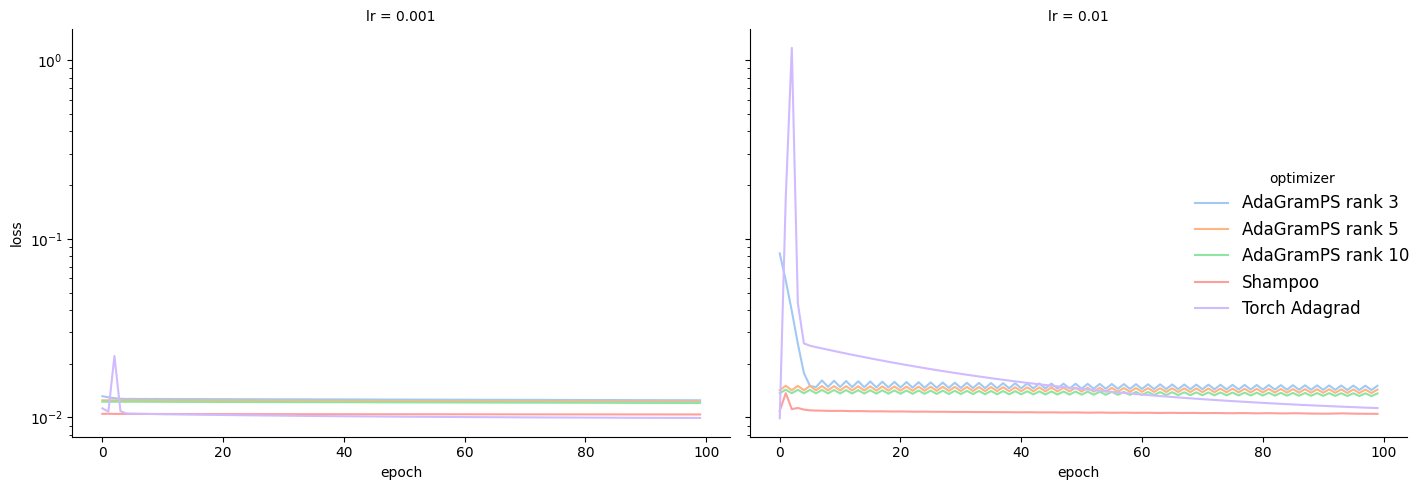

In [ ]:
plt.figure(figsize=(15, 8))
grid = sns.FacetGrid(
    data=df.query("lr != 0.1"),
    col='lr',
    height=5,
    aspect=1.2,
    sharey=True
)

grid.map_dataframe(
    sns.lineplot,
    x='epoch',
    y='loss',
    hue='optimizer',
    palette='pastel',
    linewidth=1.5
)

grid.set_titles(col_template="lr = {col_name}")

grid.add_legend(title='optimizer', fontsize=12)
grid.set_titles(fontsize=15)

for ax in grid.axes.flat:
    ax.set_yscale('log')

plt.tight_layout()
plt.show()


In [177]:
df.to_csv('ranks_shampoo_torch.csv', index=False)